In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("12-health_risk_classification.csv")

In [3]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [8]:
#bmi_score -> boy kiloya göre çıkarılan indeks skorları(sağlıklı,şişman,obez gibi)
#blood_pressure_variation -> tansiyondaki değişimler
#activity_level_index -> aktif yaşam skoru(spor yapıyorsa vs yüksek dieğr durumlarda düşük)
#high_risk_flag -> sağlık riski

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [10]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


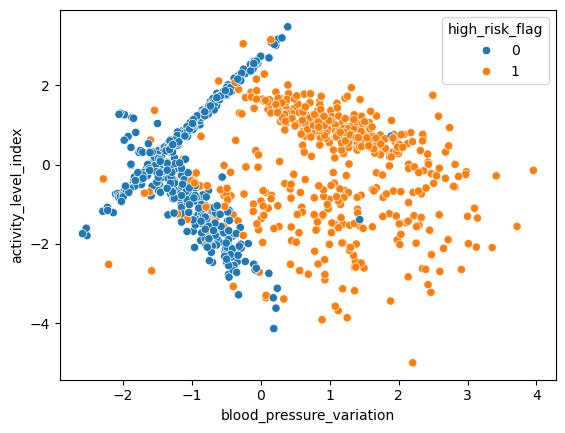

In [11]:
sns.scatterplot(x=df["blood_pressure_variation"], y=df["activity_level_index"], hue=df["high_risk_flag"])
plt.show()
                

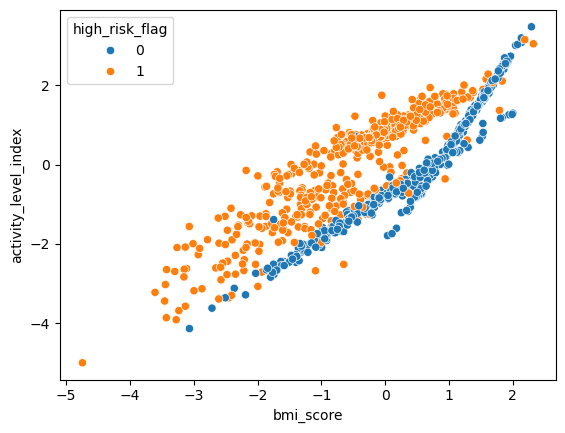

In [12]:
sns.scatterplot(x=df["bmi_score"], y=df["activity_level_index"], hue=df["high_risk_flag"])
plt.show()

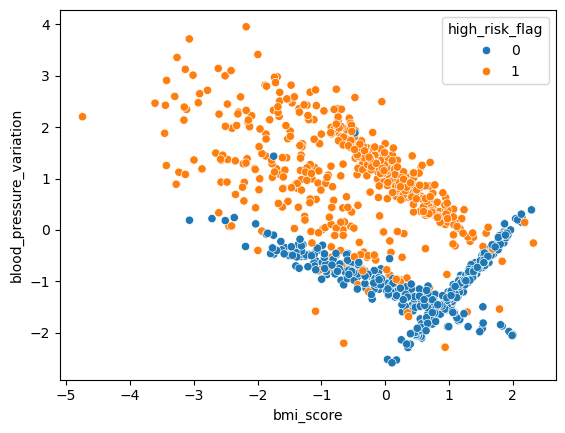

In [13]:
sns.scatterplot(x=df["bmi_score"], y=df["blood_pressure_variation"], hue=df["high_risk_flag"])
plt.show()

In [14]:
df["high_risk_flag"].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [16]:
X = df.drop("high_risk_flag",axis=1)
y = df["high_risk_flag"]

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

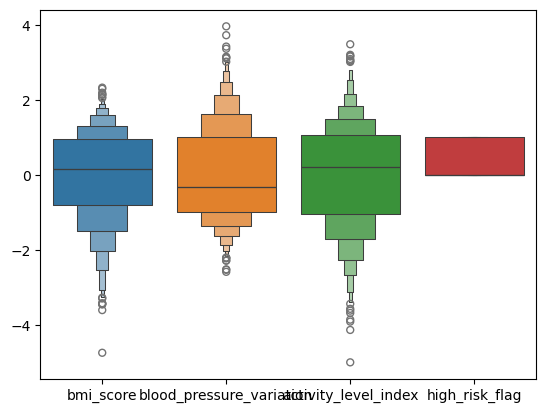

In [18]:
sns.boxenplot(df)
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm="auto",weights="uniform")


In [25]:
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [26]:
y_pred = classifier.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score ", accuracy_score(y_pred, y_test))
print("classification report", classification_report(y_pred, y_test))

confusion matrix: 
 [[124  10]
 [  2 114]]
accuracy score  0.952
classification report               precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [35]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree",weights="uniform")
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [36]:
y_pred = classifier.predict(X_test_scaled)
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score ", accuracy_score(y_pred, y_test))
print("classification report", classification_report(y_pred, y_test))

confusion matrix: 
 [[124  10]
 [  2 114]]
accuracy score  0.952
classification report               precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [37]:
#n_neighbors -> komşu sayısı
classifier = KNeighborsClassifier(n_neighbors=3, algorithm="kd_tree",weights="uniform")
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=3)

In [38]:
y_pred = classifier.predict(X_test_scaled)
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score ", accuracy_score(y_pred, y_test))
print("classification report", classification_report(y_pred, y_test))

confusion matrix: 
 [[125   9]
 [  1 115]]
accuracy score  0.96
classification report               precision    recall  f1-score   support

           0       0.99      0.93      0.96       134
           1       0.93      0.99      0.96       116

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [39]:
classifier = KNeighborsClassifier(n_neighbors=350, algorithm="kd_tree",weights="uniform")
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=350)

In [40]:
y_pred = classifier.predict(X_test_scaled)
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score ", accuracy_score(y_pred, y_test))
print("classification report", classification_report(y_pred, y_test))

confusion matrix: 
 [[124  17]
 [  2 107]]
accuracy score  0.924
classification report               precision    recall  f1-score   support

           0       0.98      0.88      0.93       141
           1       0.86      0.98      0.92       109

    accuracy                           0.92       250
   macro avg       0.92      0.93      0.92       250
weighted avg       0.93      0.92      0.92       250



In [41]:
df_reg = pd.read_csv("12-house_energy_regression.csv")

In [43]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [44]:
#avg_indoor_temp_change -> evin içindeki hava değişimi
# outdoor_humidity_level -> evin dışındaki nem değeri yüzde olarak
#daily_energy_consumption_kwh -> kilowatt cinsinden enerji harcaması

In [45]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [48]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


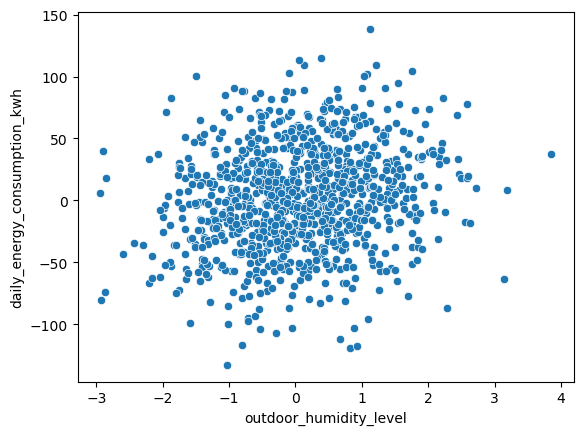

In [49]:
sns.scatterplot(x=df_reg["outdoor_humidity_level"], y=df_reg["daily_energy_consumption_kwh"])
plt.show()
              

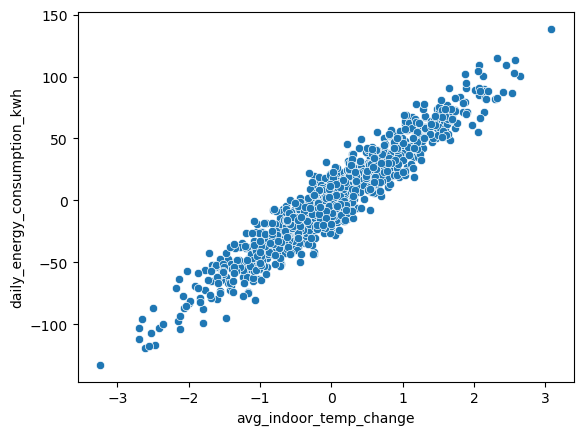

In [50]:
sns.scatterplot(x=df_reg["avg_indoor_temp_change"], y=df_reg["daily_energy_consumption_kwh"])
plt.show()

In [51]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [53]:
X = df_reg.drop("daily_energy_consumption_kwh",axis=1)
y = df_reg["daily_energy_consumption_kwh"]

In [58]:
X_train,X_test,y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [59]:
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
from sklearn.neighbors import KNeighborsRegressor

In [61]:
regressor =KNeighborsRegressor(n_neighbors=5,algorithm="auto")


In [62]:
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor()

In [63]:
y_pred = regressor.predict(X_test_scaled)

In [64]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [65]:
print("r2 score:", r2_score(y_pred, y_test))
print("mean absolute error", mean_absolute_error(y_pred, y_test))
print("mean squared error", mean_squared_error(y_pred, y_test))

r2 score: 0.9044159059426151
mean absolute error 9.228754406902722
mean squared error 135.6610827281179


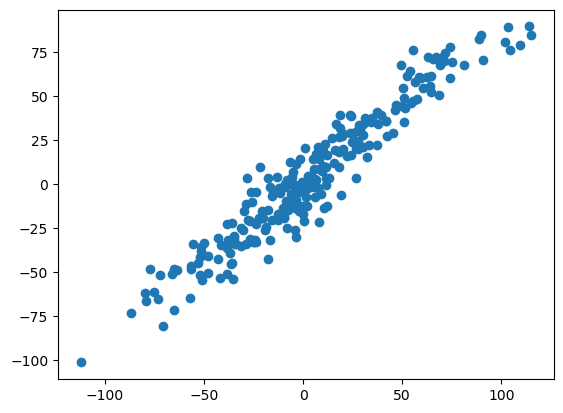

In [66]:
plt.scatter(y_test,y_pred)
plt.show()

r2 score: 0.9023613319814769
mean absolute error 9.326118628600977
mean squared error 134.62063167240598


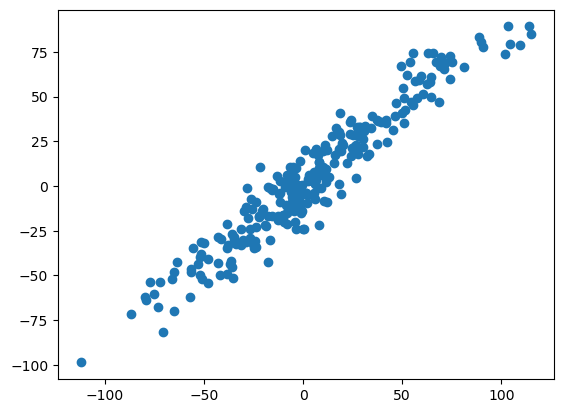

In [67]:
regressor =KNeighborsRegressor(n_neighbors=7,algorithm="auto")
regressor.fit(X_train_scaled,y_train)
y_pred = regressor.predict(X_test_scaled)
print("r2 score:", r2_score(y_pred, y_test))
print("mean absolute error", mean_absolute_error(y_pred, y_test))
print("mean squared error", mean_squared_error(y_pred, y_test))
plt.scatter(y_test,y_pred)
plt.show()

r2 score: 0.8660895359938452
mean absolute error 9.38261331951149
mean squared error 152.147396398559


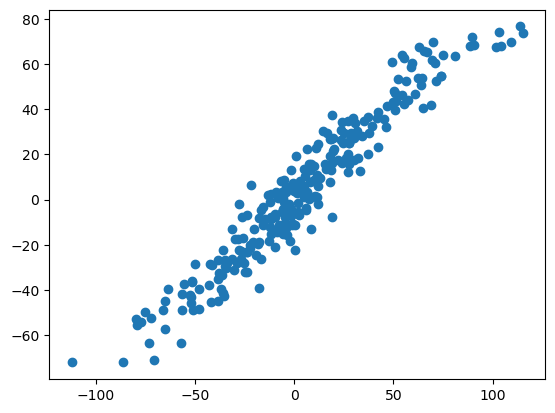

In [68]:
regressor =KNeighborsRegressor(n_neighbors=35,algorithm="auto")
regressor.fit(X_train_scaled,y_train)
y_pred = regressor.predict(X_test_scaled)
print("r2 score:", r2_score(y_pred, y_test))
print("mean absolute error", mean_absolute_error(y_pred, y_test))
print("mean squared error", mean_squared_error(y_pred, y_test))
plt.scatter(y_test,y_pred)
plt.show()